=== Fetching trials with history ===


Fetching full records: 100%|████████████████████████████████████████████████████████████| 500/500 [02:53<00:00,  2.87it/s]


Fetched 500 studies

=== Building snapshot dataset ===


Building snapshots: 100%|████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 22811.25it/s]


Snapshot dataset: 1455 rows from 495 trials
snapshot_months  label
3                0        366
                 1        129
6                0        364
                 1        125
12               0        353
                 1        118
Name: count, dtype: int64

=== Training early warning models ===

Month 3 model
CV AUC: 0.778 ± 0.027
Hold-out AUC: 0.876  Avg Precision: 0.909
              precision    recall  f1-score   support

     Success       0.81      0.86      0.83        29
     Failure       0.85      0.79      0.81        28

    accuracy                           0.82        57
   macro avg       0.83      0.82      0.82        57
weighted avg       0.83      0.82      0.82        57


Month 6 model
CV AUC: 0.767 ± 0.028
Hold-out AUC: 0.875  Avg Precision: 0.907
              precision    recall  f1-score   support

     Success       0.83      0.86      0.85        29
     Failure       0.85      0.81      0.83        27

    accuracy                           

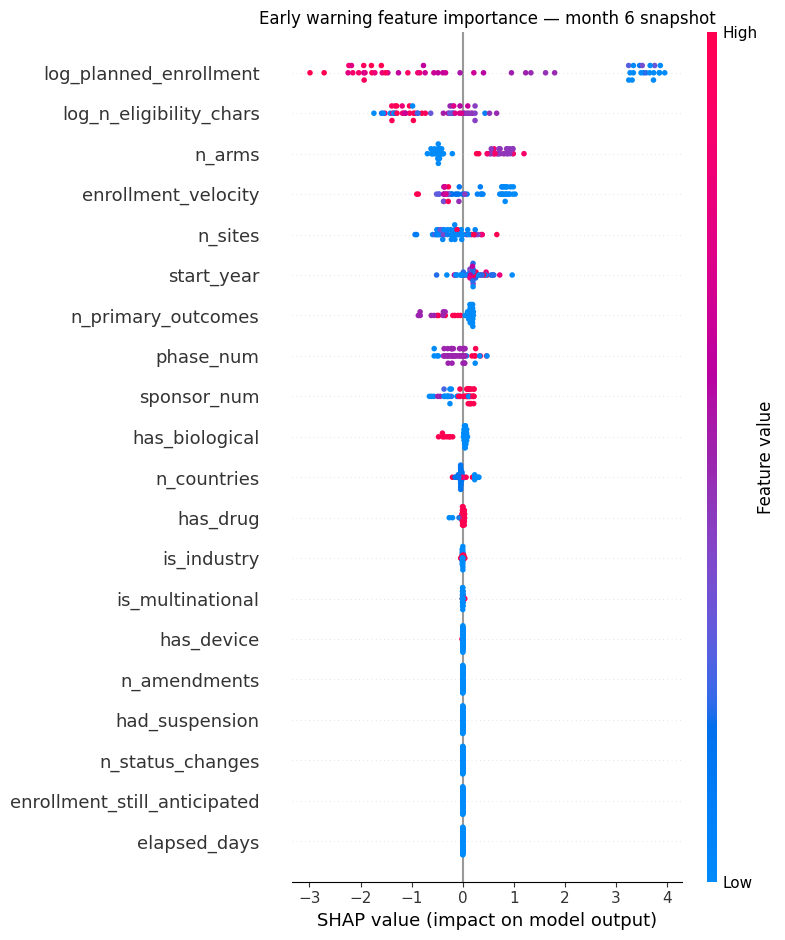


=== Survival model ===


<lifelines.CoxPHFitter: fitted with 484 total observations, 362 right-censored observations>
             duration col = 'duration_days'
                event col = 'label'
                penalizer = 0.5
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 484
number of events observed = 122
   partial log-likelihood = -648.07
         time fit was run = 2026-04-27 04:18:14 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
phase_num               -0.07      0.94      0.09           -0.24            0.11                0.78                1.12
is_industry              0.11      1.11      0.12           -0.13            0.35                0.88                1.41
log_planned_enrollment  -0.20      0.82      0.03           -0.26           -0.14                0.77                0.87
n_arms                  -0.00      1.00      0.03           -0.06            0.06                0.94                1.06
is_multinational        -0.13      0.88      0.14           -0.40            0.15                0.67                1.16
n_primary_outcomes      -0.04      0.96      0.04           -0.11            0.03                0.90                1.03
log_n_eligibility_chars  0.04      1.04      0.06           -0.08            0.15                0.92                1.17
has_drug                -0.00      1.00      0.15           -0.30            0.29                0.74                1.34
enrollment_velocity     -0.03      0.97      0.03           -0.08            0.02                0.93                1.02
n_sites                 -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
start_year               0.03      1.03      0.01            0.01            0.04                1.01                1.04

                         cmp to     z      p  -log2(p)
covariate                                             
phase_num                  0.00 -0.73   0.46      1.11
is_industry                0.00  0.89   0.37      1.42
log_planned_enrollment     0.00 -6.36 <0.005     32.22
n_arms                     0.00 -0.07   0.94      0.09
is_multinational           0.00 -0.92   0.36      1.47
n_primary_outcomes         0.00 -1.14   0.25      1.99
log_n_eligibility_chars    0.00  0.58   0.56      0.83
has_drug                   0.00 -0.03   0.98      0.03
enrollment_velocity        0.00 -1.11   0.27      1.90
n_sites                    0.00 -0.24   0.81      0.30
start_year                 0.00  3.66 <0.005     11.97
---
Concordance = 0.83
Partial AIC = 1318.14
log-likelihood ratio test = 66.63 on 11 df
-log2(p) of ll-ratio test = 30.81


=== Scoring a live trial ===
Fetching NCT00275951...

Failure probability for NCT00275951:
  Month  3: 3.0%  
  Month  6: 7.2%  █
  Month 12: 3.7%  


In [37]:
import time
import requests
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime, timedelta

BASE_URL = "https://clinicaltrials.gov/api/v2/studies"


# DATA ACQUISITION

def fetch_trial_detail(nct_id: str) -> dict | None:
    try:
        r = requests.get(f"{BASE_URL}/{nct_id}", timeout=20)
        r.raise_for_status()
        return r.json()
    except Exception:
        return None


def fetch_trials_with_history(
    condition: str = "",
    phases: list[str] = None,
    statuses: list[str] = None,
    max_studies: int = 1000,
    page_size: int = 100,
) -> list[dict]:
    if statuses is None:
        statuses = ["COMPLETED", "TERMINATED", "WITHDRAWN"]

    params = {
        "format": "json",
        "pageSize": min(page_size, 1000),
        "filter.overallStatus": "|".join(statuses),
        "countTotal": "true",
    }
    if condition:
        params["query.cond"] = condition
    if phases:
        params["filter.advanced"] = " OR ".join(f"AREA[Phase]{p}" for p in phases)

    nct_ids = []
    next_token = None

    with tqdm(total=max_studies, desc="Collecting NCT IDs") as pbar:
        while len(nct_ids) < max_studies:
            if next_token:
                params["pageToken"] = next_token
            elif "pageToken" in params:
                del params["pageToken"]

            r = requests.get(BASE_URL, params=params, timeout=30)
            r.raise_for_status()
            data = r.json()
            batch = data.get("studies", [])
            if not batch:
                break

            for s in batch:
                nct_id = s.get("protocolSection", {}).get("identificationModule", {}).get("nctId")
                if nct_id:
                    nct_ids.append(nct_id)

            pbar.update(len(batch))
            next_token = data.get("nextPageToken")
            if not next_token:
                break
            time.sleep(0.3)

    studies = []
    for nct_id in tqdm(nct_ids[:max_studies], desc="Fetching full records"):
        detail = fetch_trial_detail(nct_id)
        if detail:
            studies.append(detail)
        time.sleep(0.15)

    return studies


# PARSING

def parse_date(date_str: str) -> datetime | None:
    for fmt in ("%Y-%m-%d", "%Y-%m", "%B %d, %Y", "%B %Y", "%Y"):
        try:
            return datetime.strptime(date_str.strip(), fmt)
        except (ValueError, AttributeError):
            continue
    return None


def extract_status_history(study: dict) -> list[dict]:
    status_mod = study.get("protocolSection", {}).get("statusModule", {})
    history = []
    for entry in status_mod.get("statusDates", []):
        d = parse_date(entry.get("date", ""))
        s = entry.get("status", "")
        if d and s:
            history.append({"date": d, "status": s})
    history.sort(key=lambda x: x["date"])
    return history


def extract_amendment_count(study: dict, cutoff_date: datetime) -> int:
    id_mod = study.get("protocolSection", {}).get("identificationModule", {})
    return sum(
        1 for v in id_mod.get("protocolVersions", [])
        if (d := parse_date(v.get("date", ""))) and d <= cutoff_date
    )


# SNAPSHOT FEATURES

SNAPSHOT_MONTHS = [3, 6, 12]

PHASE_ORDER = {
    "EARLY_PHASE1": 0, "PHASE1": 1, "PHASE1_PHASE2": 1.5,
    "PHASE2": 2, "PHASE2_PHASE3": 2.5, "PHASE3": 3, "PHASE4": 4, "NA": -1,
}
SPONSOR_ORDER = {"INDUSTRY": 0, "NIH": 1, "OTHER_GOV": 2, "INDIVIDUAL": 3, "OTHER": 4}

FEATURE_COLS = [
    "phase_num", "sponsor_num", "is_industry",
    "log_planned_enrollment", "n_arms", "n_countries", "is_multinational",
    "n_primary_outcomes", "log_n_eligibility_chars",
    "has_drug", "has_device", "has_biological", "n_sites",
    "n_status_changes", "had_suspension", "n_amendments",
    "enrollment_velocity", "enrollment_still_anticipated",
    "status_is_recruiting", "status_is_active_not_rec",
    "status_is_suspended", "status_is_not_yet_rec",
    "elapsed_days", "start_year",
]


def build_snapshot(study: dict, snapshot_months: int) -> dict | None:
    proto             = study.get("protocolSection", {})
    id_mod            = proto.get("identificationModule", {})
    status_mod        = proto.get("statusModule", {})
    design_mod        = proto.get("designModule", {})
    eligibility_mod   = proto.get("eligibilityModule", {})
    sponsor_mod       = proto.get("sponsorCollaboratorsModule", {})
    outcomes_mod      = proto.get("outcomesModule", {})
    locations_mod     = proto.get("contactsLocationsModule", {})
    interventions_mod = proto.get("armsInterventionsModule", {})

    nct_id     = id_mod.get("nctId", "")
    start_date = parse_date(status_mod.get("startDateStruct", {}).get("date", ""))
    if not start_date:
        return None

    cutoff = start_date + timedelta(days=snapshot_months * 30.4)

    final_status = status_mod.get("overallStatus", "")
    if final_status == "COMPLETED":
        label = 0
    elif final_status in ("TERMINATED", "WITHDRAWN"):
        label = 1
    else:
        return None

    end_date = parse_date(
        status_mod.get("completionDateStruct", {}).get("date", "")
        or status_mod.get("primaryCompletionDateStruct", {}).get("date", "")
    )
    duration_days = (end_date - start_date).days if end_date and end_date > start_date else None
    if duration_days and duration_days < snapshot_months * 30.4:
        return None

    phases             = design_mod.get("phases", [])
    enrollment_info    = design_mod.get("enrollmentInfo", {})
    planned_enrollment = enrollment_info.get("count") or 0
    enrollment_type    = enrollment_info.get("type", "")
    lead_sponsor       = sponsor_mod.get("leadSponsor", {})
    sponsor_class      = lead_sponsor.get("class", "OTHER")
    eligibility_text   = eligibility_mod.get("eligibilityCriteria", "")
    arms               = interventions_mod.get("armGroups", [])
    intervention_types = {iv.get("type", "") for iv in interventions_mod.get("interventions", [])}
    locations          = locations_mod.get("locations", [])
    countries          = {loc.get("country", "") for loc in locations if loc.get("country")}
    primary_outcomes   = outcomes_mod.get("primaryOutcomes", [])

    status_history     = extract_status_history(study)
    status_at_snapshot = "UNKNOWN"
    n_status_changes   = 0
    had_suspension     = 0
    for entry in status_history:
        if entry["date"] <= cutoff:
            status_at_snapshot = entry["status"]
            n_status_changes  += 1
            if entry["status"] in ("SUSPENDED", "TEMPORARILY_NOT_AVAILABLE"):
                had_suspension = 1

    elapsed_days = (cutoff - start_date).days

    return {
        "nct_id":                       nct_id,
        "snapshot_months":              snapshot_months,
        "start_year":                   start_date.year,
        "label":                        label,
        "duration_days":                duration_days,
        "phase_num":                    PHASE_ORDER.get(phases[0] if phases else "NA", -1),
        "sponsor_num":                  SPONSOR_ORDER.get(sponsor_class, 4),
        "is_industry":                  int(sponsor_class == "INDUSTRY"),
        "log_planned_enrollment":       np.log1p(planned_enrollment),
        "n_arms":                       len(arms),
        "n_countries":                  len(countries),
        "is_multinational":             int(len(countries) > 1),
        "n_primary_outcomes":           len(primary_outcomes),
        "log_n_eligibility_chars":      np.log1p(len(eligibility_text)),
        "has_drug":                     int("DRUG" in intervention_types),
        "has_device":                   int("DEVICE" in intervention_types),
        "has_biological":               int("BIOLOGICAL" in intervention_types),
        "n_sites":                      len(locations),
        "n_status_changes":             n_status_changes,
        "had_suspension":               had_suspension,
        "n_amendments":                 extract_amendment_count(study, cutoff),
        "enrollment_velocity":          planned_enrollment / max(elapsed_days, 1),
        "enrollment_still_anticipated": int(enrollment_type == "ANTICIPATED"),
        "status_is_recruiting":         int(status_at_snapshot == "RECRUITING"),
        "status_is_active_not_rec":     int(status_at_snapshot == "ACTIVE_NOT_RECRUITING"),
        "status_is_suspended":          int(status_at_snapshot == "SUSPENDED"),
        "status_is_not_yet_rec":        int(status_at_snapshot == "NOT_YET_RECRUITING"),
        "elapsed_days":                 elapsed_days,
    }


def build_snapshot_dataset(studies: list[dict], snapshot_months_list: list[int] = SNAPSHOT_MONTHS) -> pd.DataFrame:
    rows = []
    for study in tqdm(studies, desc="Building snapshots"):
        for m in snapshot_months_list:
            row = build_snapshot(study, m)
            if row:
                rows.append(row)

    df = pd.DataFrame(rows)
    print(f"Snapshot dataset: {len(df)} rows from {df['nct_id'].nunique()} trials")
    print(df.groupby("snapshot_months")["label"].value_counts())
    return df


# MODEL TRAINING

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, classification_report, average_precision_score
from xgboost import XGBClassifier


def build_clf_pipeline() -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", XGBClassifier(
            n_estimators=400, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=2, eval_metric="auc",
            random_state=42, n_jobs=-1,
        )),
    ])


def train_early_warning_models(df: pd.DataFrame, cutoff_year: int = 2020) -> dict:
    models = {}
    for months in sorted(df["snapshot_months"].unique()):
        subset = df[df["snapshot_months"] == months].copy()
        train  = subset[subset["start_year"] < cutoff_year]
        test   = subset[subset["start_year"] >= cutoff_year]

        if len(train) < 50 or len(test) < 20:
            print(f"Month {months}: insufficient data, skipping")
            continue

        X_train, y_train = train[FEATURE_COLS], train["label"]
        X_test,  y_test  = test[FEATURE_COLS],  test["label"]

        pipe   = build_clf_pipeline()
        cv_auc = cross_val_score(pipe, X_train, y_train,
                                 cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                 scoring="roc_auc")
        pipe.fit(X_train, y_train)
        y_proba = pipe.predict_proba(X_test)[:, 1]
        y_pred  = pipe.predict(X_test)

        print(f"\nMonth {months} model")
        print(f"CV AUC: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
        print(f"Hold-out AUC: {roc_auc_score(y_test, y_proba):.3f}  Avg Precision: {average_precision_score(y_test, y_proba):.3f}")
        print(classification_report(y_test, y_pred, target_names=["Success", "Failure"]))

        models[months] = {"pipeline": pipe, "X_test": X_test, "y_test": y_test, "y_proba": y_proba}

    return models


# SURVIVAL MODEL

def train_survival_model(df: pd.DataFrame, snapshot_months: int = 6):
    try:
        from lifelines import CoxPHFitter
    except ImportError:
        print("Install lifelines: pip install lifelines")
        return None

    cox_features = [
        "phase_num", "is_industry", "log_planned_enrollment",
        "n_arms", "is_multinational", "n_primary_outcomes",
        "log_n_eligibility_chars", "has_drug",
        "enrollment_velocity", "n_sites", "start_year",
        "duration_days", "label",
    ]

    subset = df[df["snapshot_months"] == snapshot_months].copy()
    cox_df = subset[cox_features].dropna()
    cox_df = cox_df[cox_df["duration_days"] > 0]

    # Drop near-zero variance columns which cause singular matrix errors
    low_var = [c for c in cox_df.columns if cox_df[c].std() < 0.01]
    cox_df  = cox_df.drop(columns=low_var)
    if low_var:
        print(f"Dropped low-variance columns: {low_var}")

    # Drop highly correlated columns to reduce collinearity
    corr    = cox_df.drop(columns=["duration_days", "label"]).corr().abs()
    upper   = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > 0.85)]
    cox_df  = cox_df.drop(columns=to_drop)
    if to_drop:
        print(f"Dropped high-correlation columns: {to_drop}")

    cph = CoxPHFitter(penalizer=0.5)
    cph.fit(cox_df, duration_col="duration_days", event_col="label")
    cph.print_summary()
    return cph


# EXPLAINABILITY

def explain_early_warning(models: dict, snapshot_months: int = 6):
    try:
        import shap
        import matplotlib.pyplot as plt
    except ImportError:
        print("Install shap and matplotlib: pip install shap matplotlib")
        return

    if snapshot_months not in models:
        print(f"No model for month {snapshot_months}")
        return

    m    = models[snapshot_months]
    pipe = m["pipeline"]
    X_t  = pd.DataFrame(pipe[:-1].transform(m["X_test"]), columns=FEATURE_COLS)

    explainer   = shap.TreeExplainer(pipe.named_steps["clf"])
    shap_values = explainer.shap_values(X_t)

    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values, X_t, feature_names=FEATURE_COLS, show=False)
    plt.title(f"Early warning feature importance — month {snapshot_months} snapshot")
    plt.tight_layout()
    plt.savefig(f"shap_early_warning_m{snapshot_months}.png", dpi=150, bbox_inches="tight")
    print(f"SHAP plot saved to shap_early_warning_m{snapshot_months}.png")
    plt.show()


# TRIAL SCORER

def score_trial(nct_id: str, models: dict) -> dict | None:
    print(f"Fetching {nct_id}...")
    study = fetch_trial_detail(nct_id)
    if not study:
        print("Could not fetch trial")
        return None

    results = {}
    for m in sorted(models.keys()):
        snap = build_snapshot(study, m)
        if snap is None:
            results[m] = None
            continue
        X    = pd.DataFrame([snap])[FEATURE_COLS]
        prob = models[m]["pipeline"].predict_proba(X)[0, 1]
        results[m] = round(prob, 3)

    print(f"\nFailure probability for {nct_id}:")
    for m, prob in results.items():
        if prob is None:
            print(f"  Month {m:2d}: insufficient data for this window")
        else:
            bar = "█" * int(prob * 20)
            print(f"  Month {m:2d}: {prob:.1%}  {bar}")

    return results


# MAIN

if __name__ == "__main__":
    print("=== Fetching trials with history ===")
    studies = fetch_trials_with_history(
        condition="cancer",
        phases=["PHASE2", "PHASE3"],
        max_studies=500,
    )
    print(f"Fetched {len(studies)} studies")

    print("\n=== Building snapshot dataset ===")
    df = build_snapshot_dataset(studies)
    df.to_csv("early_warning_snapshots.csv", index=False)

    print("\n=== Training early warning models ===")
    models = train_early_warning_models(df, cutoff_year=2020)

    print("\n=== SHAP feature importance ===")
    explain_early_warning(models, snapshot_months=6)

    print("\n=== Survival model ===")
    cph = train_survival_model(df, snapshot_months=6)

    print("\n=== Scoring a live trial ===")
    score_trial("NCT00275951", models)

In [38]:
def save_results_to_txt(models: dict, cph, df: pd.DataFrame, output_path: str = "results.txt"):
    import io
    from contextlib import redirect_stdout
    from sklearn.metrics import roc_auc_score, classification_report, average_precision_score

    with open(output_path, "w") as f:

        f.write("EARLY WARNING MODEL RESULTS\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Total trials in dataset: {df['nct_id'].nunique()}\n")
        f.write(f"Total snapshots: {len(df)}\n\n")

        f.write("DATASET SUMMARY\n")
        f.write(str(df.groupby("snapshot_months")["label"].value_counts().rename({0: "Success", 1: "Failure"})))
        f.write("\n\n")

        f.write("CLASSIFIER RESULTS BY SNAPSHOT WINDOW\n")
        for months, m in sorted(models.items()):
            y_test  = m["y_test"]
            y_proba = m["y_proba"]
            y_pred  = m["pipeline"].predict(m["X_test"])

            f.write(f"\nMonth {months} snapshot\n")
            f.write(f"Hold-out AUC:    {roc_auc_score(y_test, y_proba):.3f}\n")
            f.write(f"Avg Precision:   {average_precision_score(y_test, y_proba):.3f}\n")
            f.write(classification_report(y_test, y_pred, target_names=["Success", "Failure"]))

        f.write("\nSURVIVAL MODEL SUMMARY\n")
        if cph is not None:
            buf = io.StringIO()
            with redirect_stdout(buf):
                cph.print_summary()
            f.write(buf.getvalue())
        else:
            f.write("Survival model did not converge.\n")

        f.write("\nFEATURE IMPORTANCE BY SNAPSHOT WINDOW\n")
        for months, m in sorted(models.items()):
            pipe = m["pipeline"]
            clf  = pipe.named_steps["clf"]
            importances = pd.Series(clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
            f.write(f"\nMonth {months} snapshot — top 10 features\n")
            f.write(importances.head(10).to_string())
            f.write("\n")

    print(f"Results saved to {output_path}")


save_results_to_txt(models, cph, df)

<lifelines.CoxPHFitter: fitted with 484 total observations, 362 right-censored observations>
             duration col = 'duration_days'
                event col = 'label'
                penalizer = 0.5
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 484
number of events observed = 122
   partial log-likelihood = -648.07
         time fit was run = 2026-04-27 04:18:14 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
phase_num               -0.07      0.94      0.09           -0.24            0.11                0.78                1.12
is_industry              0.11      1.11      0.12           -0.13            0.35                0.88                1.41
log_planned_enrollment  -0.20      0.82      0.03           -0.26           -0.14                0.77                0.87
n_arms                  -0.00      1.00      0.03           -0.06            0.06                0.94                1.06
is_multinational        -0.13      0.88      0.14           -0.40            0.15                0.67                1.16
n_primary_outcomes      -0.04      0.96      0.04           -0.11            0.03                0.90                1.03
log_n_eligibility_chars  0.04      1.04      0.06           -0.08            0.15                0.92                1.17
has_drug                -0.00      1.00      0.15           -0.30            0.29                0.74                1.34
enrollment_velocity     -0.03      0.97      0.03           -0.08            0.02                0.93                1.02
n_sites                 -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
start_year               0.03      1.03      0.01            0.01            0.04                1.01                1.04

                         cmp to     z      p  -log2(p)
covariate                                             
phase_num                  0.00 -0.73   0.46      1.11
is_industry                0.00  0.89   0.37      1.42
log_planned_enrollment     0.00 -6.36 <0.005     32.22
n_arms                     0.00 -0.07   0.94      0.09
is_multinational           0.00 -0.92   0.36      1.47
n_primary_outcomes         0.00 -1.14   0.25      1.99
log_n_eligibility_chars    0.00  0.58   0.56      0.83
has_drug                   0.00 -0.03   0.98      0.03
enrollment_velocity        0.00 -1.11   0.27      1.90
n_sites                    0.00 -0.24   0.81      0.30
start_year                 0.00  3.66 <0.005     11.97
---
Concordance = 0.83
Partial AIC = 1318.14
log-likelihood ratio test = 66.63 on 11 df
-log2(p) of ll-ratio test = 30.81

Results saved to results.txt
